# Modelo de Precificação Dinâmica (Surge Pricing) — Dataset Uber/99

**Objetivo:** construir um modelo de regressão que estime o **preço por minuto** de uma corrida a partir do contexto (relação oferta/demanda, fidelidade do cliente, horário, tipo de veículo), isolando o componente de "surge" do efeito óbvio da duração da corrida.

**Por que não é um problema de elasticidade:** este dataset não tem quantidade demandada variando em resposta ao preço (cada linha é uma corrida única, já realizada) — não dá pra medir "se o preço sobe X%, quantos desistem". O que dá pra responder aqui é **"dado o contexto, que preço por minuto faz sentido cobrar?"** — um problema de precificação dinâmica (regressão).

## 1. Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carregamento dos dados

In [2]:
data = pd.read_csv('dynamic_pricing.csv')
data.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


## 3. Dimensões e estrutura

In [3]:
print(data.shape)
data.info()

(1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.2+ KB


## 4. Valores nulos

In [4]:
data.isnull().sum()

Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

## 5. Estatísticas descritivas

In [5]:
data.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


## 6. Distribuição das variáveis categóricas

In [6]:
for col in ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']:
    print(data[col].value_counts())
    print()

Location_Category
Urban       346
Rural       332
Suburban    322
Name: count, dtype: int64

Customer_Loyalty_Status
Silver     367
Regular    320
Gold       313
Name: count, dtype: int64

Time_of_Booking
Night        276
Afternoon    247
Morning      246
Evening      231
Name: count, dtype: int64

Vehicle_Type
Premium    522
Economy    478
Name: count, dtype: int64



## 7. Por que não usar o preço bruto como target

O preço da corrida (`Historical_Cost_of_Ride`) tem correlação muito alta com a duração esperada — isso mascara o efeito de oferta/demanda que queremos capturar.

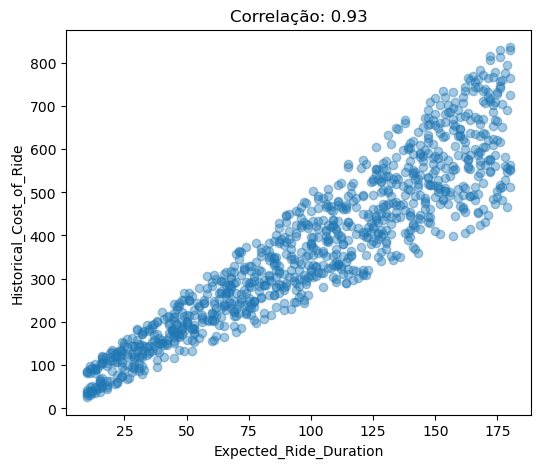

In [7]:
plt.figure(figsize=(6, 5))
plt.scatter(data['Expected_Ride_Duration'], data['Historical_Cost_of_Ride'], alpha=0.4)
plt.xlabel('Expected_Ride_Duration')
plt.ylabel('Historical_Cost_of_Ride')
plt.title(f"Correlação: {data['Expected_Ride_Duration'].corr(data['Historical_Cost_of_Ride']):.2f}")
plt.show()

## 8. Engenharia de variáveis

- `demand_supply_ratio`: proxy de pressão de demanda (quanto maior, menos motoristas disponíveis por passageiro)
- `price_per_min`: preço normalizado pela duração — isola o componente de surge, que é o que queremos modelar

In [8]:
data['demand_supply_ratio'] = data['Number_of_Riders'] / data['Number_of_Drivers']
data['price_per_min'] = data['Historical_Cost_of_Ride'] / data['Expected_Ride_Duration']

data[['demand_supply_ratio', 'price_per_min']].describe()

,demand_supply_ratio,price_per_min
count,1000.000000,1000.000000
mean,3.235461,3.890068
std,2.533519,0.912955
min,1.112360,2.502595
25%,1.658793,3.243703
50%,2.357143,3.772418
75%,3.800000,4.347651
max,17.600000,8.889501


## 9. `price_per_min` x relação oferta/demanda

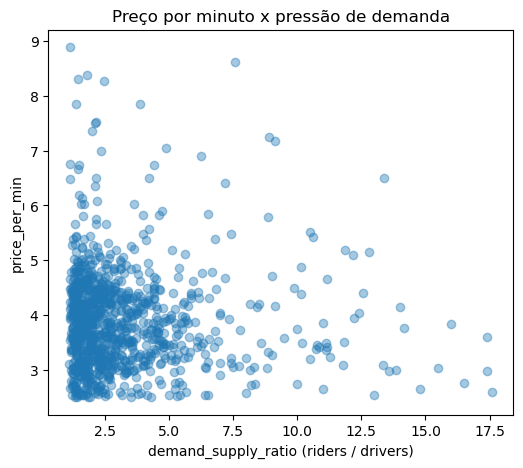

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(data['demand_supply_ratio'], data['price_per_min'], alpha=0.4)
plt.xlabel('demand_supply_ratio (riders / drivers)')
plt.ylabel('price_per_min')
plt.title('Preço por minuto x pressão de demanda')
plt.show()

## 10. Matriz de correlação (variáveis numéricas)

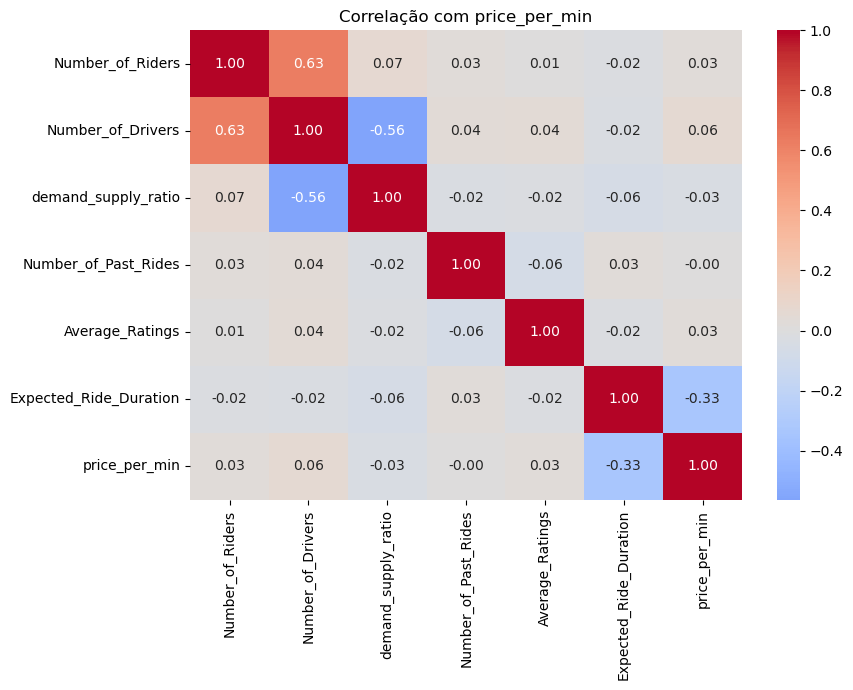

In [10]:
plt.figure(figsize=(9, 7))
num_cols = ['Number_of_Riders', 'Number_of_Drivers', 'demand_supply_ratio',
            'Number_of_Past_Rides', 'Average_Ratings', 'Expected_Ride_Duration', 'price_per_min']
sns.heatmap(data[num_cols].corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('Correlação com price_per_min')
plt.tight_layout()
plt.show()

## 11. Preparação dos dados

One-hot encoding das variáveis categóricas e split treino/teste. `Historical_Cost_of_Ride` e `Expected_Ride_Duration` ficam fora das features — já foram usadas para construir o target (`price_per_min`), incluí-las de volta seria vazamento de dado.

In [11]:
from sklearn.model_selection import train_test_split

cat_cols = ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

features = ['demand_supply_ratio', 'Number_of_Riders', 'Number_of_Drivers',
            'Number_of_Past_Rides', 'Average_Ratings'] + \
           [c for c in data_encoded.columns if c.startswith(tuple(cat_cols))]

X = data_encoded[features].astype(float)
y = data_encoded['price_per_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (800, 13) | Teste: (200, 13)


## 12. Modelo baseline: Regressão Linear (OLS)

Para interpretar o sinal e a magnitude de cada fator no preço por minuto.

In [12]:
import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train)
modelo_ols = sm.OLS(y_train, X_train_ols).fit()
print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:          price_per_min   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     12.70
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.39e-25
Time:                        11:46:45   Log-Likelihood:                -988.31
No. Observations:                 800   AIC:                             2005.
Df Residuals:                     786   BIC:                             2070.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

## 13. Avaliação do OLS fora da amostra

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error

X_test_ols = sm.add_constant(X_test, has_constant='add')
y_pred_ols = modelo_ols.predict(X_test_ols)

print(f"R² (teste): {r2_score(y_test, y_pred_ols):.3f}")
print(f"MAE (teste): {mean_absolute_error(y_test, y_pred_ols):.3f}")

R² (teste): 0.191
MAE (teste): 0.587


## 14. Modelo principal: XGBoost

Captura interações não-lineares entre oferta/demanda, fidelidade e horário que a regressão linear não pega.

In [14]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"R² (teste): {r2_score(y_test, y_pred_xgb):.3f}")
print(f"MAE (teste): {mean_absolute_error(y_test, y_pred_xgb):.3f}")

R² (teste): 0.118
MAE (teste): 0.622


## 15. Importância das variáveis (XGBoost)

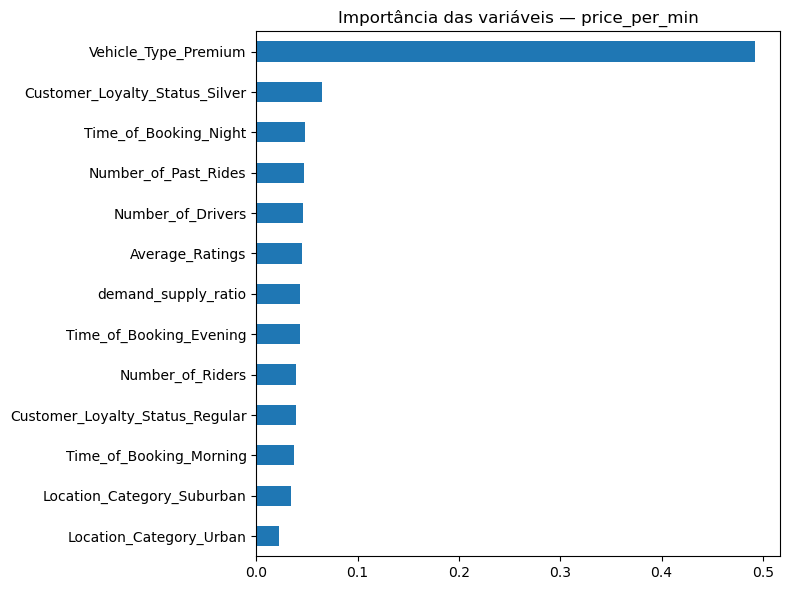

Vehicle_Type_Premium               0.492252
Customer_Loyalty_Status_Silver     0.064833
Time_of_Booking_Night              0.047570
Number_of_Past_Rides               0.047286
Number_of_Drivers                  0.046112
Average_Ratings                    0.044929
demand_supply_ratio                0.043572
Time_of_Booking_Evening            0.042648
Number_of_Riders                   0.038889
Customer_Loyalty_Status_Regular    0.038874
Time_of_Booking_Morning            0.037304
Location_Category_Suburban         0.033787
Location_Category_Urban            0.021944
dtype: float32


In [15]:
importancias = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Importância das variáveis — price_per_min')
plt.tight_layout()
plt.show()

print(importancias)

## 16. Diagnóstico: de onde vem o R²?

O R² de 0,19 é baixo. Antes de aceitar o número, vale investigar a causa: testamos quanto do poder explicativo vem *só* de `Vehicle_Type` (a variável de maior importância no XGBoost), comparado com o modelo completo (13 variáveis).

In [16]:
media_por_veiculo = data.groupby('Vehicle_Type')['price_per_min'].transform('mean')
r2_so_vehicle = r2_score(data['price_per_min'], media_por_veiculo)
print(f"R² usando só a média de price_per_min por Vehicle_Type: {r2_so_vehicle:.3f}")

print("\nCorrelação de cada variável numérica com price_per_min:")
print(data[['demand_supply_ratio', 'Number_of_Riders', 'Number_of_Drivers',
            'Number_of_Past_Rides', 'Average_Ratings']].corrwith(data['price_per_min']))

R² usando só a média de price_per_min por Vehicle_Type: 0.173

Correlação de cada variável numérica com price_per_min:
demand_supply_ratio    -0.033246
Number_of_Riders        0.030104
Number_of_Drivers       0.057256
Number_of_Past_Rides   -0.000327
Average_Ratings         0.030536
dtype: float64


**Leitura do diagnóstico:** o R² obtido só com `Vehicle_Type` (~0,17) é quase idêntico ao R² do modelo completo com 13 variáveis (0,19). Ou seja, praticamente todo o poder explicativo vem dessa única variável categórica. As demais — incluindo `demand_supply_ratio`, a peça central da hipótese de "surge" por oferta/demanda — têm correlação próxima de zero com `price_per_min`. Isso bate com os p-values do OLS (seção 12): só `Vehicle_Type_Premium` é estatisticamente significativo (p < 0,001); todas as outras variáveis têm p-value > 0,29, ou seja, não são distinguíveis de ruído neste dataset.

## 17. Comparação dos modelos

In [17]:
resultados = pd.DataFrame({
    'Modelo': ['OLS (baseline)', 'XGBoost'],
    'R2_teste': [r2_score(y_test, y_pred_ols), r2_score(y_test, y_pred_xgb)],
    'MAE_teste': [mean_absolute_error(y_test, y_pred_ols), mean_absolute_error(y_test, y_pred_xgb)],
})
resultados

,Modelo,R2_teste,MAE_teste
0,OLS (baseline),0.190982,0.587057
1,XGBoost,0.117810,0.622063


## 18. Conclusões

**Resultado:** OLS (R² = 0,191) superou o XGBoost (R² = 0,118) fora da amostra neste dataset.

**Causa raiz (seção 16):** o dataset não sustenta a hipótese de "surge pricing" por oferta/demanda. Praticamente todo o R² vem de uma única variável categórica (`Vehicle_Type`, R²≈0,17 sozinha); `demand_supply_ratio`, `Number_of_Riders`, `Number_of_Drivers`, `Number_of_Past_Rides` e `Average_Ratings` têm correlação próxima de zero com o preço por minuto e p-value > 0,29 no OLS — estatisticamente indistinguíveis de ruído. O dataset provavelmente foi gerado com uma fórmula do tipo `preço = tarifa_base(tipo_veículo) × duração × ruído`, sem de fato injetar relação entre oferta/demanda e preço, apesar de essas colunas existirem e "convidarem" para essa história.

**Por que o XGBoost perdeu para o OLS:** com pouco sinal real disponível (~0,17 de R² possível) e 800 linhas de treino, o XGBoost usa sua flexibilidade extra para encaixar ruído (overfitting) em vez de padrão real — modelo mais complexo não é sinônimo de modelo melhor quando não há não-linearidade genuína para capturar.

**Achado de negócio (revisado):** o único driver de preço com evidência estatística neste dataset é a segmentação de produto (Premium x Economy). A hipótese de precificação dinâmica por pressão de oferta/demanda **não se confirma** nos dados — um resultado negativo, mas honesto e defensável, que veio de investigar a causa do R² baixo em vez de só reportá-lo.

**Próximos passos possíveis:**
- Com um dataset real (não sintético), repetir esse diagnóstico antes de qualquer modelagem — testar a correlação bruta de cada variável com o target economiza tempo de tuning em variáveis sem sinal.
- Se o objetivo fosse só prever o preço total da corrida (`Historical_Cost_of_Ride`), manter `Expected_Ride_Duration` como feature normalmente traria R² bem mais alto — é uma pergunta de negócio diferente da que investigamos aqui.

## 19. Insights

**Insight do projeto de Precificação Dinâmica (Uber/99):**

"Eu queria testar se o preço de corrida reagia à oferta e demanda — a hipótese clássica de
surge pricing. Rodei os modelos e o R² ficou baixo, entre 12% e 19%. Em vez de aceitar isso,
investiguei a causa: isolei que praticamente todo o poder explicativo vinha de uma única
variável, o tipo de veículo — Premium vs Economy — e testei a correlação de cada variável de
oferta/demanda com o preço, e todas deram estatisticamente igual a zero. Concluí que a
hipótese de surge pricing simplesmente não se sustentava nesse dataset. É um resultado
negativo, mas é um resultado correto, e cheguei nele com rigor."